<a href="https://colab.research.google.com/github/meghana507/ai-ml-practice-project/blob/main/13_6_Gradient_Clipping_in_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Clipping in Keras

<ol>1. Loading the dataset</ol>
<ol>2. Pre-processing the data</ol>
<ol>3. Creating training and validation set</ol>
<ol>4. Defining the model architecture</ol>
<ol>5. Compiling the model</ol>
<ol> <ol>* Define clipvalue while defining the optimizer</ol></ol>
<ol>6. Training the model</ol>
<ol>7. Evaluating model performance</ol>

## 1. Loading the dataset

In [1]:
# import necessary libraries and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# importing layers from keras
from keras.layers import Dense, InputLayer
from keras.models import Sequential
# importing adam optimizer from keras optimizer module
from keras.optimizers import Adam

# train_test_split to create training and validation set
from sklearn.model_selection import train_test_split
# accuracy_score to calculate the accuracy of predictions
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/AV/Course_Handouts_Fundamentals_of_Deep_Learning/Dataset.zip

Archive:  /content/drive/MyDrive/AV/Course_Handouts_Fundamentals_of_Deep_Learning/Dataset.zip
   creating: Dataset/
  inflating: Dataset/emergency_classification.csv  
   creating: Dataset/images/
  inflating: Dataset/images/0.jpg    
  inflating: Dataset/images/10.jpg   
  inflating: Dataset/images/1002.jpg  
  inflating: Dataset/images/1006.jpg  
  inflating: Dataset/images/1007.jpg  
  inflating: Dataset/images/1009.jpg  
  inflating: Dataset/images/1013.jpg  
  inflating: Dataset/images/1014.jpg  
  inflating: Dataset/images/1016.jpg  
  inflating: Dataset/images/1019.jpg  
  inflating: Dataset/images/102.jpg  
  inflating: Dataset/images/1020.jpg  
  inflating: Dataset/images/1022.jpg  
  inflating: Dataset/images/1023.jpg  
  inflating: Dataset/images/1026.jpg  
  inflating: Dataset/images/1031.jpg  
  inflating: Dataset/images/1035.jpg  
  inflating: Dataset/images/1036.jpg  
  inflating: Dataset/images/1037.jpg  
  inflating: Dataset/images/104.jpg  
  inflating: Dataset/images

In [3]:
# reading the csv file
data = pd.read_csv('/content/emergency_classification.csv')

In [4]:
# create random number generator
seed = 42
rng = np.random.RandomState(seed)

In [5]:
import shutil
shutil.copytree('/content/drive/MyDrive/images/images', '/content/images')

'/content/images'

In [6]:
# load images and store it in numpy array

# empty list to store the images
X = []
# iterating over each image
for img_name in data.image_names:
    # loading the image using its name
    img = plt.imread('/content/images/' + img_name)
    # saving each image in the list
    X.append(img)

# converting the list of images into array
X=np.array(X)

# storing the target variable in separate variable
y = data.emergency_or_not.values

## 2. Pre-processing the data

In [7]:
# converting 3 dimensional image to 1 dimensional image
X = X.reshape(X.shape[0], 224*224*3)
X.shape

(2352, 150528)

In [8]:
# normalizing the pixel values
X = X / X.max()

# minimum and maximum pixel values of images after normalizing
X.min(), X.max()

(np.float64(0.0), np.float64(1.0))

## 3. Creating training and validation set

In [9]:
# creating a training and validation set
X_train, X_valid, y_train, y_valid=train_test_split(X,y,test_size=0.3, random_state=seed)

In [10]:
# shape of training and validation set
(X_train.shape, y_train.shape), (X_valid.shape, y_valid.shape)

(((1646, 150528), (1646,)), ((706, 150528), (706,)))

## 4. Defining the model architecture

In [11]:
# defining the model architecture with dropout layer
model=Sequential()

model.add(InputLayer(input_shape=(224*224*3,)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


## 5. Compiling the model

In [13]:
# defining the adam optimizer and setting the learning rate as 10^-5 and adding clip value to clip the gradients
adam = Adam(learning_rate=1e-5, clipvalue=1)

In [14]:
# compiling the model

# defining loss as binary crossentropy
# defining optimizer as Adam
# defining metrics as accuracy

model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

## 6. Training the model

In [15]:
# training the model for 100 epochs

model_history = model.fit(X_train, y_train, epochs=100, batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 736ms/step - accuracy: 0.4585 - loss: 0.7797 - val_accuracy: 0.5609 - val_loss: 0.6876
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 491ms/step - accuracy: 0.5748 - loss: 0.6831 - val_accuracy: 0.5609 - val_loss: 0.6864
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 695ms/step - accuracy: 0.5876 - loss: 0.6792 - val_accuracy: 0.5609 - val_loss: 0.6859
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 495ms/step - accuracy: 0.5777 - loss: 0.6813 - val_accuracy: 0.5609 - val_loss: 0.6856
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 710ms/step - accuracy: 0.5837 - loss: 0.6795 - val_accuracy: 0.5609 - val_loss: 0.6852
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 553ms/step - accuracy: 0.5904 - loss: 0.6776 - val_accuracy: 0.5609 - val_loss: 0.6851
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 495ms/step - accuracy: 0.5690 - loss: 0.6829 - val_accuracy: 0.5609 - val_loss: 0.6850
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 689ms/step - accuracy: 0.5623 - loss: 0.6846 - val_a

## 7. Evaluating model performance

In [17]:
prediction = model.predict(X_valid)
prediction = prediction.reshape(706,)

# converting probabilities to classes
prediction_int = prediction >= 0.5
prediction_int = prediction_int.astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step


In [18]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, prediction_int), '%')

Accuracy on validation set: 0.6628895184135978 %


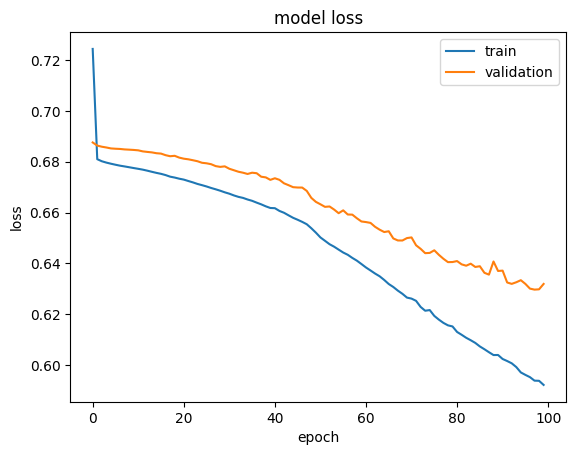

In [19]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()